# **Img Distances**
### *BONUS TASK 01*

TASK: Implementieren Sie ein Python Notebook,
um alle paarweisen euklidischen Abstände zwischen drei
hochaufgelösten Bildern (> 1 MP, zwei “ähnliche” und 1
“unähnliches”) zu berechnen und anzuzeigen (Bildpaar +
Abstand als Zahl). Was fällt Ihnen auf?

In [59]:
import cv2
import os
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import glob

### **Approach**

refer to paper: "On the Euclidean Distance of Images"

The euclidian Distance: 

--- Checking Files ---
[SKIP] Ente_2.jpeg: 0.23 MB (< 1 MB)
[KEEP] Hahn_2.jpeg: 6.61 MB
[KEEP] Ente_1.jpeg: 1.18 MB
[KEEP] Hahn_1.jpeg: 6.91 MB

--- Cropping to Common Size: 2048x1536 ---


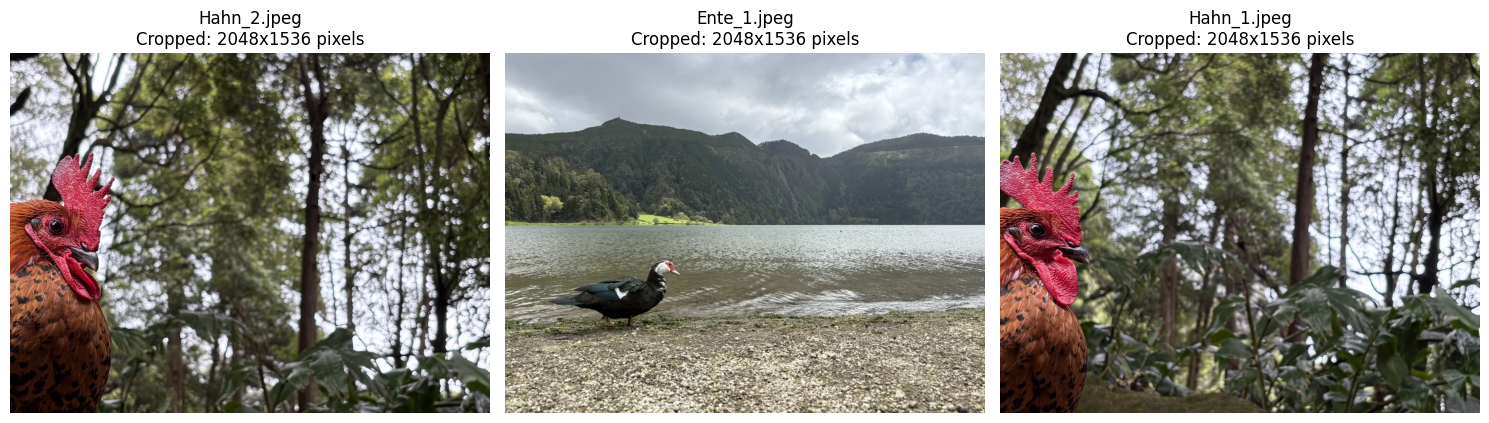

In [60]:
### load the images, crop them to same size and display them (check for size > 1 MB)

def load_and_crop_images(image_paths):
    valid_images = [] # Will store (path, img, size_mb)
    
    print("--- Checking Files ---")
    for path in image_paths:
        size_bytes = os.path.getsize(path)
        
        # ADJUSTMENT: Use 1,000,000 to match macOS Finder (Base-10)
        # Use 1024 * 1024 if you want strict computer science MiB
        file_size_mb = size_bytes / (1_000_000) 
        
        if file_size_mb > 1.0:  # Threshold
            img = cv2.imread(path)
            if img is not None:
                print(f"[KEEP] {os.path.basename(path)}: {file_size_mb:.2f} MB")
                valid_images.append({'path': path, 'img': img, 'size': file_size_mb})
            else:
                print(f"[ERR ] Error loading: {path}")
        else:
            print(f"[SKIP] {os.path.basename(path)}: {file_size_mb:.2f} MB (< 1 MB)")
    
    if not valid_images:
        return [], []
    
    # Find minimum dimensions
    min_height = min(item['img'].shape[0] for item in valid_images)
    min_width = min(item['img'].shape[1] for item in valid_images)
    
    print(f"\n--- Cropping to Common Size: {min_width}x{min_height} ---")
    
    cropped_data = []
    
    for item in valid_images:
        img = item['img']
        height, width, _ = img.shape
        
        # Center Crop Calculation
        start_x = (width - min_width) // 2
        start_y = (height - min_height) // 2
        cropped_img = img[start_y:start_y + min_height, start_x:start_x + min_width]
        
        # Store the cropped image AND the original metadata together
        cropped_data.append({
            'img': cropped_img,
            'path': item['path'],
            'size': item['size']
        })
        
    return cropped_data

def display_images(data_list):
    if not data_list:
        return

    num_images = len(data_list)
    plt.figure(figsize=(5 * num_images, 5)) # Adjust width based on count
    
    for i, item in enumerate(data_list):
        plt.subplot(1, num_images, i + 1)
        
        # Convert BGR (OpenCV) to RGB (Matplotlib)
        plt.imshow(cv2.cvtColor(item['img'], cv2.COLOR_BGR2RGB))
        
        filename = os.path.basename(item['path'])
        plt.title(f"{filename}\nCropped: {item['img'].shape[1]}x{item['img'].shape[0]} pixels")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()


# Update your path here
image_folder = '/Users/fregler001/Documents/10_uni/00_05_Semester/deep_learning/WDSKI_WiSe25-Deep_Learning/Bonus_Tasks/01/imgs'
    
# Robust globbing (case insensitive usually requires regex, but this covers standard extensions)
extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG']
image_files = []
for ext in extensions:
        image_files.extend(glob.glob(os.path.join(image_folder, ext)))
    
# Process
cropped_imgs = load_and_crop_images(image_files)
    
if cropped_imgs:
        display_images(cropped_imgs)
else:
        print("No images met the criteria.")

**Mathematical & Formal Justification:**
- Representation: An image $I$ with resolution $H \times W$ and $C$ color channels is flattened into a single vector $\mathbf{v}$ of length $N = H \times W \times C$.
- Justification: This assumes that the images are geometrically identical. The distance represents the photometric difference (intensity difference) at every specific coordinate.

In [61]:
### Now we calculate the euclidien difference between the images
def euclidean_distance(img1, img2):
    # Ensure both images have the same shape
    if img1.shape != img2.shape:
        raise ValueError("Images must have the same dimensions for Euclidean distance calculation.")
    
    # Calculate the Euclidean distance
    distance = np.sqrt(np.sum((img1.astype("float") - img2.astype("float")) ** 2))
    return distance

def calculate_image_distances(images):
    num_images = len(images)
    distances = np.zeros((num_images, num_images))
    
    for i in range(num_images):
        for j in range(num_images):
            if i != j:
                distances[i, j] = euclidean_distance(images[i], images[j])
            else:
                distances[i, j] = 0.0  # Distance to itself is zero
    
    return distances

# calculate and print distances
if cropped_imgs:
    # Extract just the image arrays from the dictionaries
    images = [item['img'] for item in cropped_imgs]
    distances = calculate_image_distances(images)
    
    print("Euclidean distances between images:")
    print(distances)
    
    # Display named distances
    print("\nNamed pairwise distances:")
    num_images = len(cropped_imgs)
    for i in range(num_images):
        for j in range(i + 1, num_images):  # Only upper triangle to avoid duplicates
            name_i = os.path.basename(cropped_imgs[i]['path']).replace('.jpeg', '').replace('.jpg', '').replace('.png', '')
            name_j = os.path.basename(cropped_imgs[j]['path']).replace('.jpeg', '').replace('.jpg', '').replace('.png', '')
            print(f"{name_i} zu {name_j}: {distances[i, j]:.2f}")

Euclidean distances between images:
[[     0.         319188.50377637 260340.83338385]
 [319188.50377637      0.         301716.45370778]
 [260340.83338385 301716.45370778      0.        ]]

Named pairwise distances:
Hahn_2 zu Ente_1: 319188.50
Hahn_2 zu Hahn_1: 260340.83
Ente_1 zu Hahn_1: 301716.45


### in more Detail:

In [62]:
# How the images are represented as pixel matrices
def show_image_representation(image):
    print("Image shape (Height x Width x Channels):", image.shape)
    flattened = image.astype(float)
    print("image vector length:", len(flattened))
    print("First 3 values of the vector:", flattened[:3])
    # could also be flattened = image.flatten().astype(float)

if cropped_imgs:
    show_image_representation(cropped_imgs[0]['img'])

Image shape (Height x Width x Channels): (1536, 2048, 3)
image vector length: 1536
First 3 values of the vector: [[[10. 12. 13.]
  [10. 12. 13.]
  [10. 12. 13.]
  ...
  [ 4.  8. 13.]
  [ 5.  9. 14.]
  [ 6. 10. 15.]]

 [[ 9. 11. 12.]
  [10. 12. 13.]
  [10. 12. 13.]
  ...
  [ 4.  8. 13.]
  [ 5.  9. 14.]
  [ 6. 10. 15.]]

 [[11. 10. 12.]
  [12. 11. 13.]
  [12. 11. 13.]
  ...
  [ 7. 11. 16.]
  [ 8. 12. 17.]
  [10. 14. 19.]]]


## **More sophisticated Approach: Histogram Distance (The Statistical Approach)**

Instead of comparing pixel positions, you compare the distribution of colors.

**Mathematical & Formal Justification:**
- Representation: The image is mapped to a probability distribution function (PDF) or a frequency vector (histogram) $\mathbf{h}$, where $h_i$ represents the count of pixels having color value $i$.
- Justification: This relaxes the spatial constraint. The distance measures the similarity in color composition/tone, ignoring where objects are located in the image.

Histogram Euclidean distances between images:
[[0.         1.35273826 0.22221982]
 [1.35273826 0.         1.25417733]
 [0.22221982 1.25417733 0.        ]]

Named pairwise histogram distances:
Hahn_2 zu Ente_1: 1.3527
Hahn_2 zu Hahn_1: 0.2222
Ente_1 zu Hahn_1: 1.2542


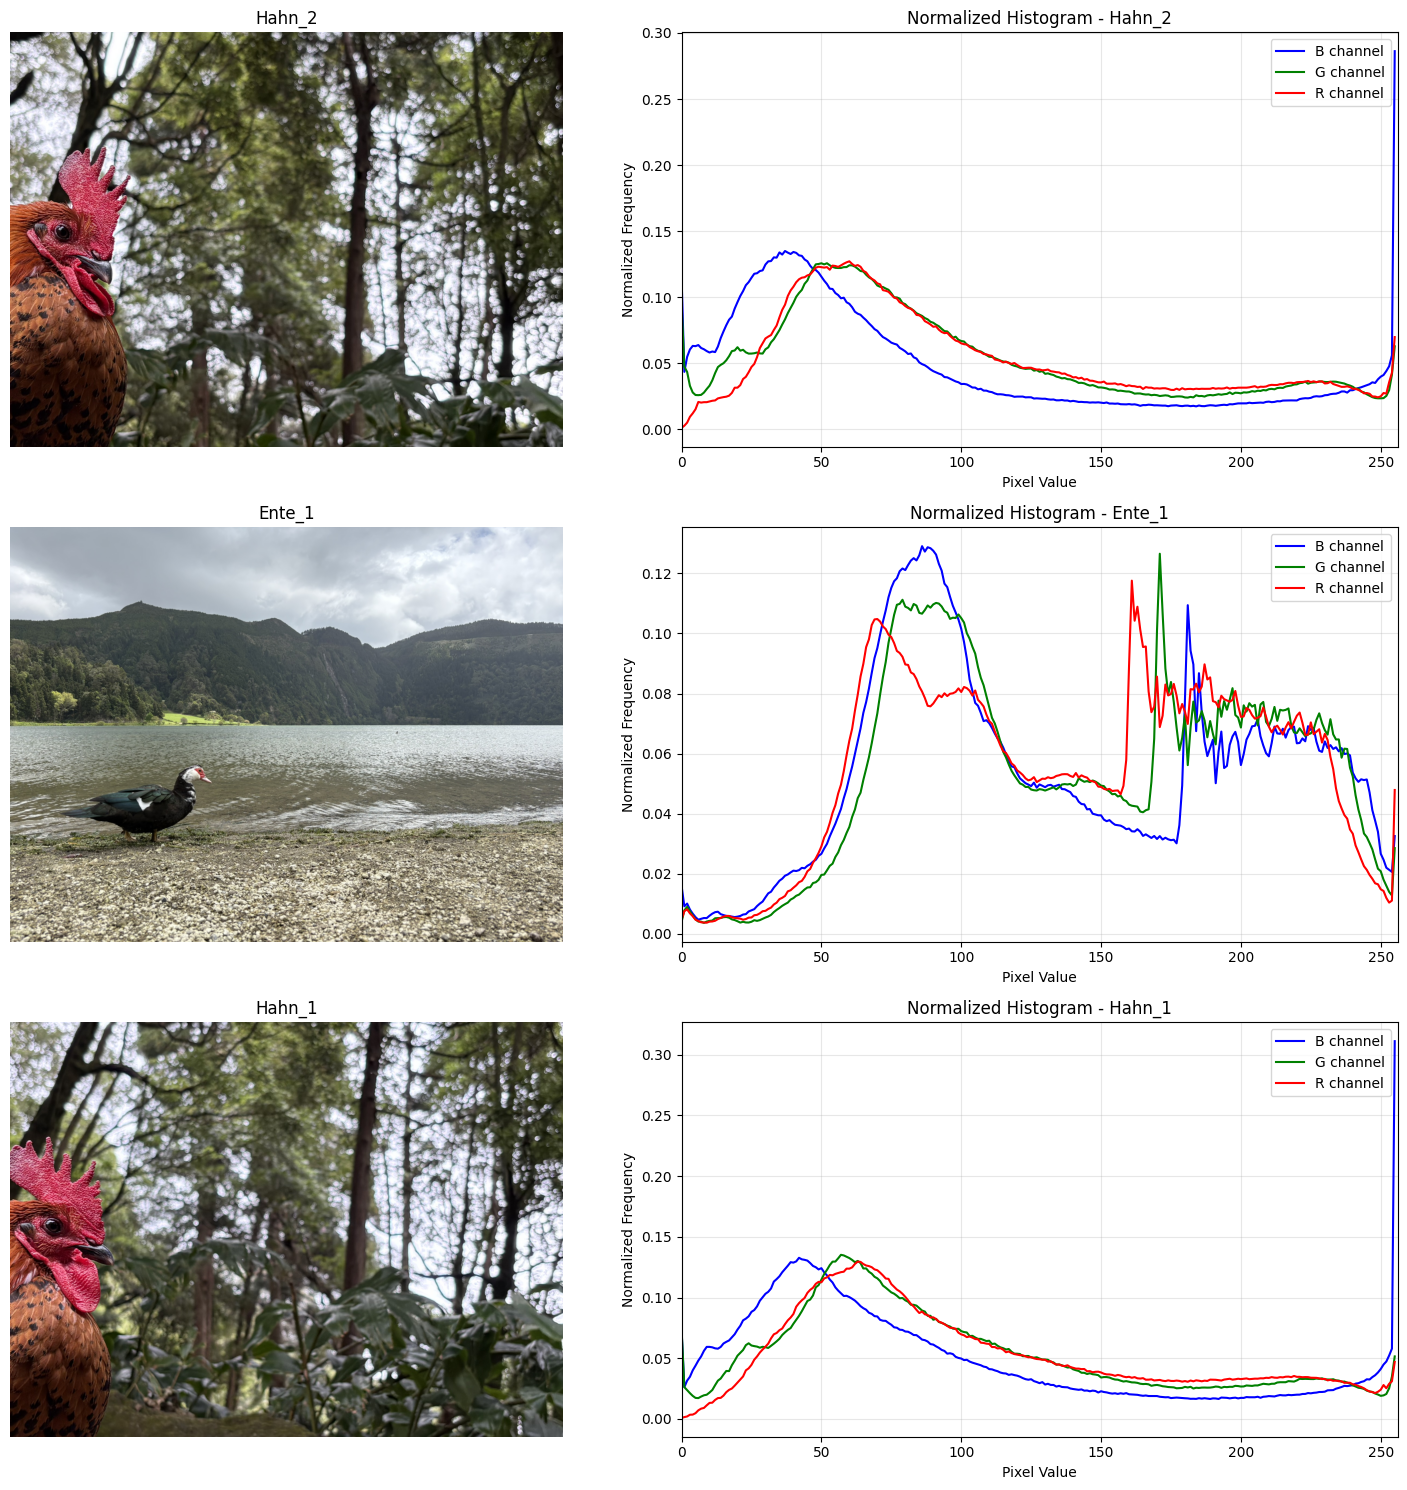

In [64]:
def histogram_euclidean_distance(img1, img2):
    # Accept numpy arrays directly instead of file paths
    # Calculate histograms (e.g., for Blue channel, or all 3)
    # Here we compute a histogram for each channel and concatenate them
    hist1 = []
    hist2 = []
    
    for i in range(3): # B, G, R channels
        # Calculate hist: images, channels, mask, histSize, ranges
        h1 = cv2.calcHist([img1], [i], None, [256], [0, 256])
        h2 = cv2.calcHist([img2], [i], None, [256], [0, 256])
        
        # Normalize the histogram so image size doesn't affect the result
        cv2.normalize(h1, h1)
        cv2.normalize(h2, h2)
        
        hist1.extend(h1.flatten())
        hist2.extend(h2.flatten())

    # Calculate distance between the feature vectors (histograms)
    dist = np.linalg.norm(np.array(hist1) - np.array(hist2))
    return dist

def calculate_histogram_distances(images):
    num_images = len(images)
    distances = np.zeros((num_images, num_images))
    
    for i in range(num_images):
        for j in range(num_images):
            if i != j:
                distances[i, j] = histogram_euclidean_distance(images[i], images[j])
            else:
                distances[i, j] = 0.0  # Distance to itself is zero
    return distances

def display_histograms(images):
    num_images = len(images)
    colors = ('b', 'g', 'r')
    
    plt.figure(figsize=(15, 5 * num_images))
    
    for idx, img_data in enumerate(cropped_imgs):
        img = img_data['img']
        img_name = os.path.basename(img_data['path']).replace('.jpeg', '').replace('.jpg', '').replace('.png', '')
        
        # Display the image
        plt.subplot(num_images, 2, 2 * idx + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"{img_name}")
        plt.axis('off')
        
        # Display the histogram
        plt.subplot(num_images, 2, 2 * idx + 2)
        for i, color in enumerate(colors):
            hist = cv2.calcHist([img], [i], None, [256], [0, 256])
            cv2.normalize(hist, hist)
            plt.plot(hist, color=color, label=f'{color.upper()} channel')
        plt.xlim([0, 256])
        plt.title(f"Normalized Histogram - {img_name}")
        plt.xlabel('Pixel Value')
        plt.ylabel('Normalized Frequency')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# calculate and print histogram distances
if cropped_imgs:
    # Extract just the image arrays from the dictionaries
    images = [item['img'] for item in cropped_imgs]
    hist_distances = calculate_histogram_distances(images)
    print("Histogram Euclidean distances between images:")
    print(hist_distances)
    
    # Display named distances
    print("\nNamed pairwise histogram distances:")
    num_images = len(cropped_imgs)
    for i in range(num_images):
        for j in range(i + 1, num_images):  # Only upper triangle to avoid duplicates
            name_i = os.path.basename(cropped_imgs[i]['path']).replace('.jpeg', '').replace('.jpg', '').replace('.png', '')
            name_j = os.path.basename(cropped_imgs[j]['path']).replace('.jpeg', '').replace('.jpg', '').replace('.png', '')
            print(f"{name_i} zu {name_j}: {hist_distances[i, j]:.4f}")
    
    display_histograms(images)